In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasist.structdata import detect_outliers
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings

from sklearn.metrics import confusion_matrix,accuracy_score,r2_score,auc,roc_auc_score,roc_curve,ConfusionMatrixDisplay,f1_score,classification_report
import pickle
from sklearn.impute import KNNImputer,SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV , cross_validate,train_test_split
warnings.filterwarnings('ignore')

In [2]:
df_survey = pd.read_csv("data/Stress_Dataset.csv")
df_survey.head()

,Gender,Age,Have you recently experienced stress in your life?,Have you noticed a rapid heartbeat or palpitations?,Have you been dealing with anxiety or tension recently?,Do you face any sleep problems or difficulties falling asleep?,Have you been dealing with anxiety or tension recently?.1,Have you been getting headaches more often than usual?,Do you get irritated easily?,Do you have trouble concentrating on your academic tasks?,...,Are you facing any difficulties with your professors or instructors?,Is your working environment unpleasant or stressful?,Do you struggle to find time for relaxation and leisure activities?,Is your hostel or home environment causing you difficulties?,Do you lack confidence in your academic performance?,Do you lack confidence in your choice of academic subjects?,Academic and extracurricular activities conflicting for you?,Do you attend classes regularly?,Have you gained/lost weight?,Which type of stress do you primarily experience?
0,0,20,3,4,2,5,1,2,1,2,...,3,1,4,1,2,1,3,1,2,Eustress (Positive Stress) - Stress that motiv...
1,0,20,2,3,2,1,1,1,1,4,...,3,2,1,1,3,2,1,4,2,Eustress (Positive Stress) - Stress that motiv...
2,0,20,5,4,2,2,1,3,4,2,...,2,2,2,1,4,1,1,2,1,Eustress (Positive Stress) - Stress that motiv...
3,1,20,3,4,3,2,2,3,4,3,...,1,1,2,1,2,1,1,5,3,Eustress (Positive Stress) - Stress that motiv...
4,0,20,3,3,3,2,2,4,4,4,...,2,3,1,2,2,4,2,2,2,Eustress (Positive Stress) - Stress that motiv...


In [3]:
df = pd.read_csv("data/StressLevelDataset.csv")
df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


In [4]:
df.insert(0, 'Age', df_survey['Age'])
df.insert(1, 'Gender', df_survey['Gender'])
df.head()


,Age,Gender,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,20.0,0.0,14,20,0,11,2,1,2,4,...,2,3,2,3,3,2,3,3,2,1
1,20.0,0.0,15,8,1,15,5,3,1,4,...,2,1,4,1,5,1,4,5,5,2
2,20.0,0.0,12,18,1,14,2,1,2,2,...,2,2,3,3,2,2,3,2,2,1
3,20.0,1.0,16,12,1,15,4,3,1,3,...,2,2,4,1,4,1,4,4,5,2
4,20.0,0.0,16,28,0,7,2,3,5,1,...,3,4,3,1,2,1,5,0,5,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           843 non-null    float64
 1   Gender                        843 non-null    float64
 2   anxiety_level                 1100 non-null   int64  
 3   self_esteem                   1100 non-null   int64  
 4   mental_health_history         1100 non-null   int64  
 5   depression                    1100 non-null   int64  
 6   headache                      1100 non-null   int64  
 7   blood_pressure                1100 non-null   int64  
 8   sleep_quality                 1100 non-null   int64  
 9   breathing_problem             1100 non-null   int64  
 10  noise_level                   1100 non-null   int64  
 11  living_conditions             1100 non-null   int64  
 12  safety                        1100 non-null   int64  
 13  bas

In [6]:
df.describe()

,Age,Gender,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,843.000000,843.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,...,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,20.071174,0.349941,11.063636,17.777273,0.492727,12.555455,2.508182,2.181818,2.660000,2.753636,...,2.772727,2.772727,2.621818,2.648182,2.649091,1.881818,2.734545,2.767273,2.617273,0.996364
std,5.429502,0.477234,6.117558,8.944599,0.500175,7.727008,1.409356,0.833575,1.548383,1.400713,...,1.433761,1.414594,1.315781,1.384579,1.529375,1.047826,1.425265,1.417562,1.530958,0.821673
min,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,6.000000,11.000000,0.000000,6.000000,1.000000,1.000000,1.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000
50%,19.000000,0.000000,11.000000,19.000000,0.000000,12.000000,3.000000,2.000000,2.500000,3.000000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.500000,3.000000,1.000000
75%,20.000000,1.000000,16.000000,26.000000,1.000000,19.000000,3.000000,3.000000,4.000000,4.000000,...,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,2.000000
max,100.000000,1.000000,21.000000,30.000000,1.000000,27.000000,5.000000,3.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000,2.000000


## Data cleaning

In [7]:
df.isnull().sum()
#This shows that there are no nulls

Age                             257
Gender                          257
anxiety_level                     0
self_esteem                       0
mental_health_history             0
depression                        0
headache                          0
blood_pressure                    0
sleep_quality                     0
breathing_problem                 0
noise_level                       0
living_conditions                 0
safety                            0
basic_needs                       0
academic_performance              0
study_load                        0
teacher_student_relationship      0
future_career_concerns            0
social_support                    0
peer_pressure                     0
extracurricular_activities        0
bullying                          0
stress_level                      0
dtype: int64

In [8]:
df.columns

Index(['Age', 'Gender', 'anxiety_level', 'self_esteem',
       'mental_health_history', 'depression', 'headache', 'blood_pressure',
       'sleep_quality', 'breathing_problem', 'noise_level',
       'living_conditions', 'safety', 'basic_needs', 'academic_performance',
       'study_load', 'teacher_student_relationship', 'future_career_concerns',
       'social_support', 'peer_pressure', 'extracurricular_activities',
       'bullying', 'stress_level'],
      dtype='object')

In [9]:
outliers = detect_outliers(df, 0, df.select_dtypes(include=np.number).columns)
print("Number of outliers:", len(outliers))

Number of outliers: 307


In [10]:
df.shape

(1100, 23)

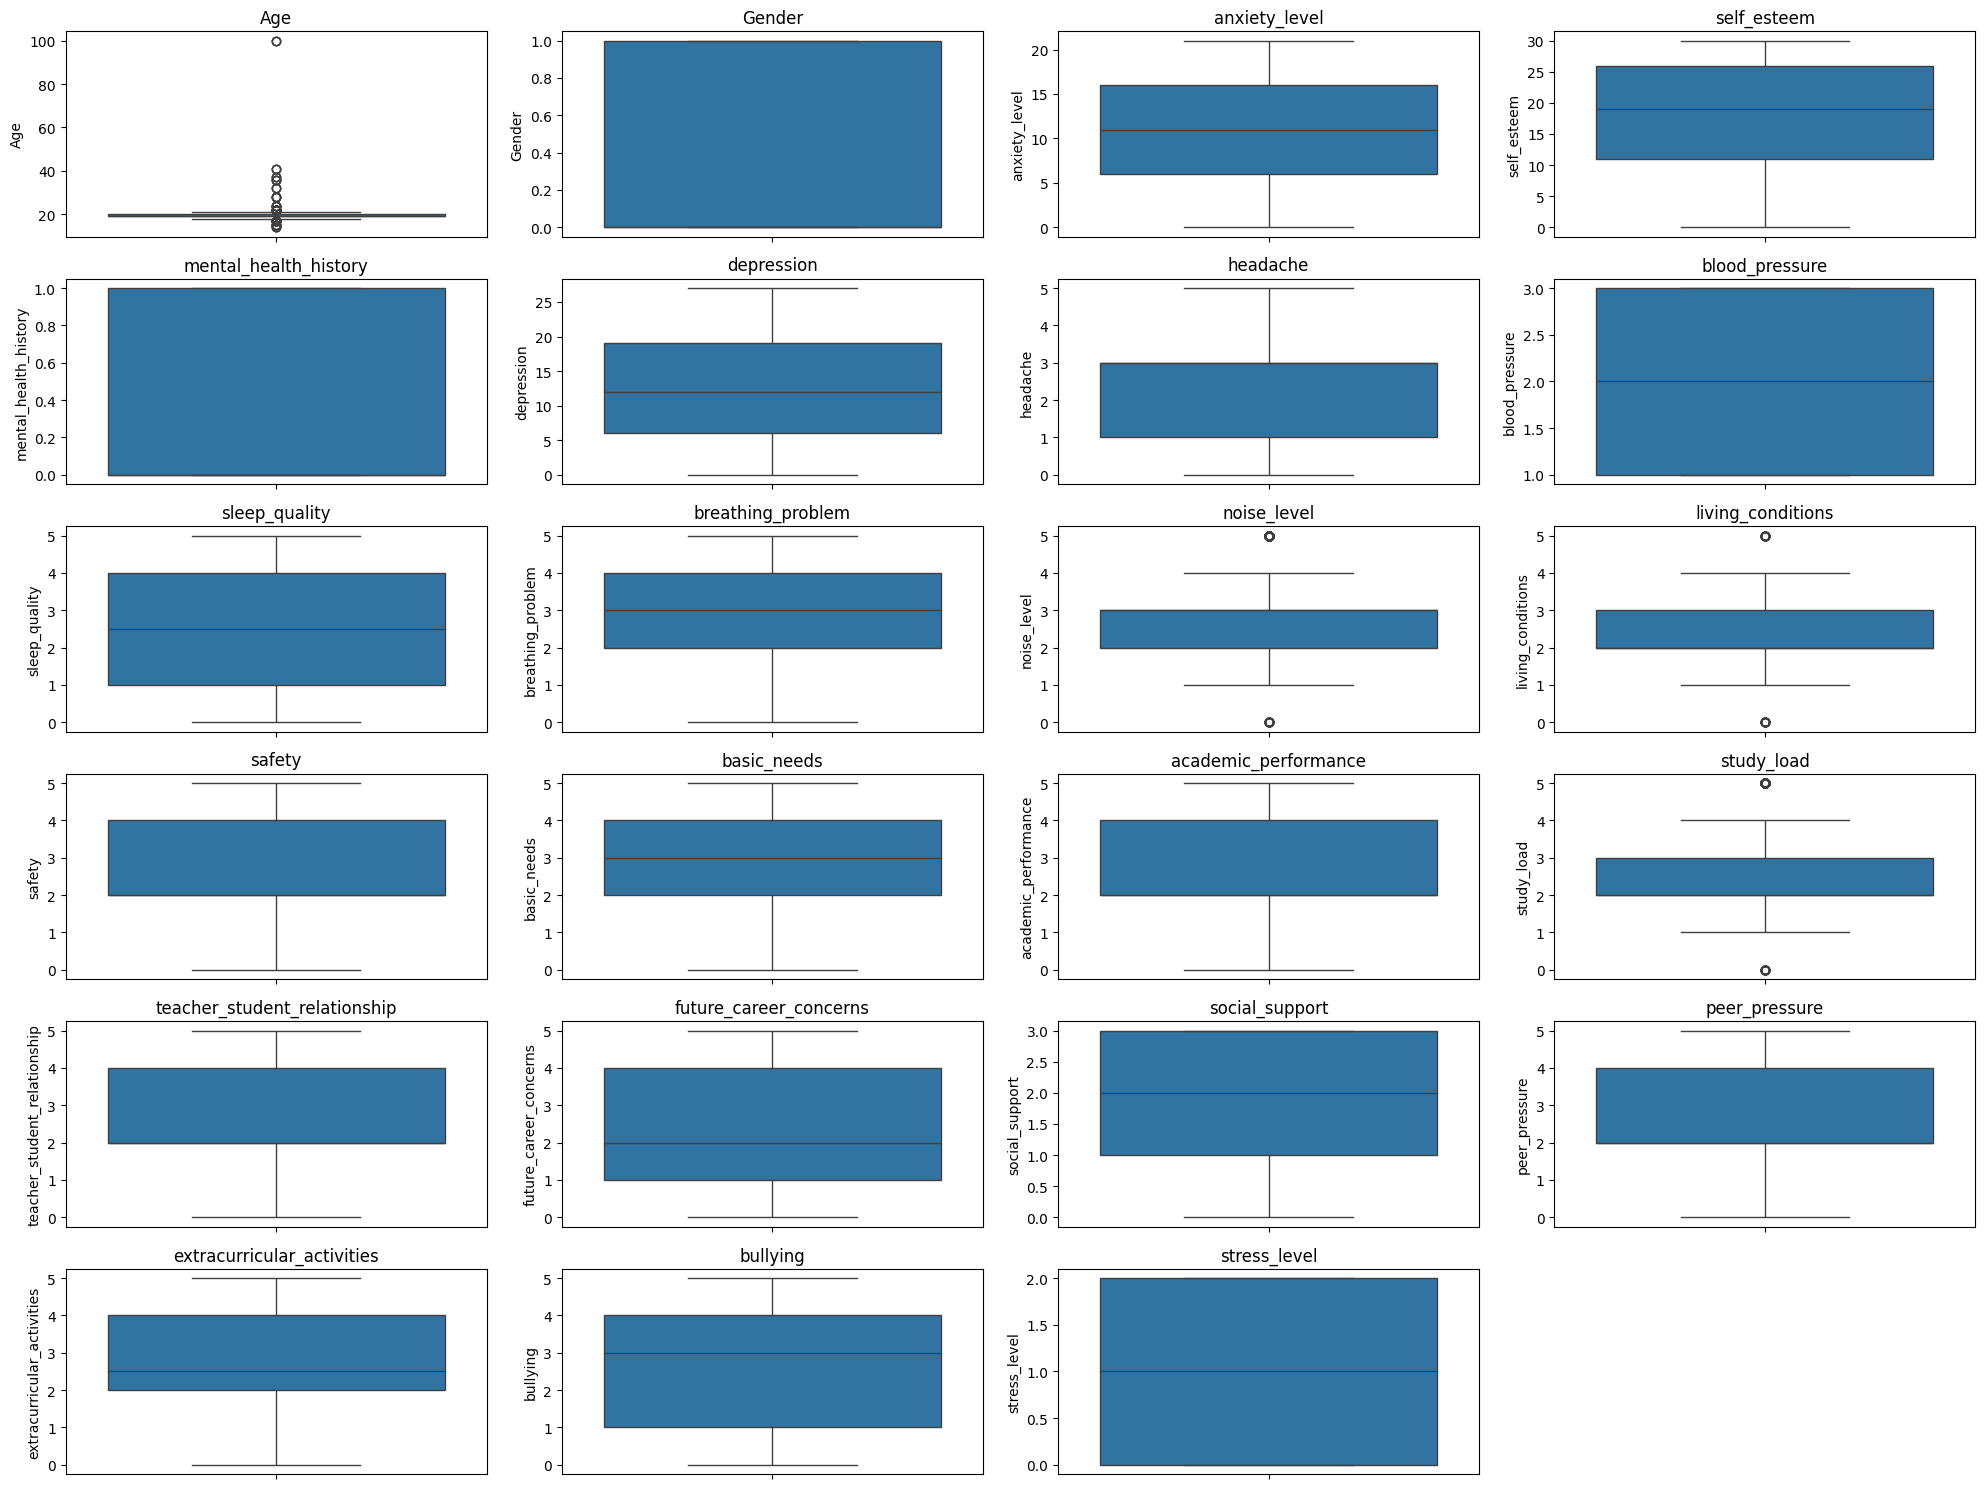

In [11]:
#The box plotting for each feature before removing outliers
plt.figure(figsize=(20,15))
numeric_cols = df.select_dtypes(include=np.number).columns
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(6, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [12]:
if len(outliers) > 0:
    df_new = df.drop(index=outliers).reset_index(drop=True)
    print("Outliers removed. New shape:", df_new.shape)
else:
    print("No outliers to remove; dataset unchanged.")

Outliers removed. New shape: (793, 23)


In [13]:
# Detect outliers specifically in the 'Age' column
age_outliers = detect_outliers(df, 0, ['Age'])

if len(age_outliers) > 0:
    df_new = df.drop(index=age_outliers).reset_index(drop=True)
    print(f"Outliers removed from 'Age' column. New shape: {df_new.shape}")
else:
    print("No outliers found in 'Age' column; dataset unchanged.")

No outliers found in 'Age' column; dataset unchanged.


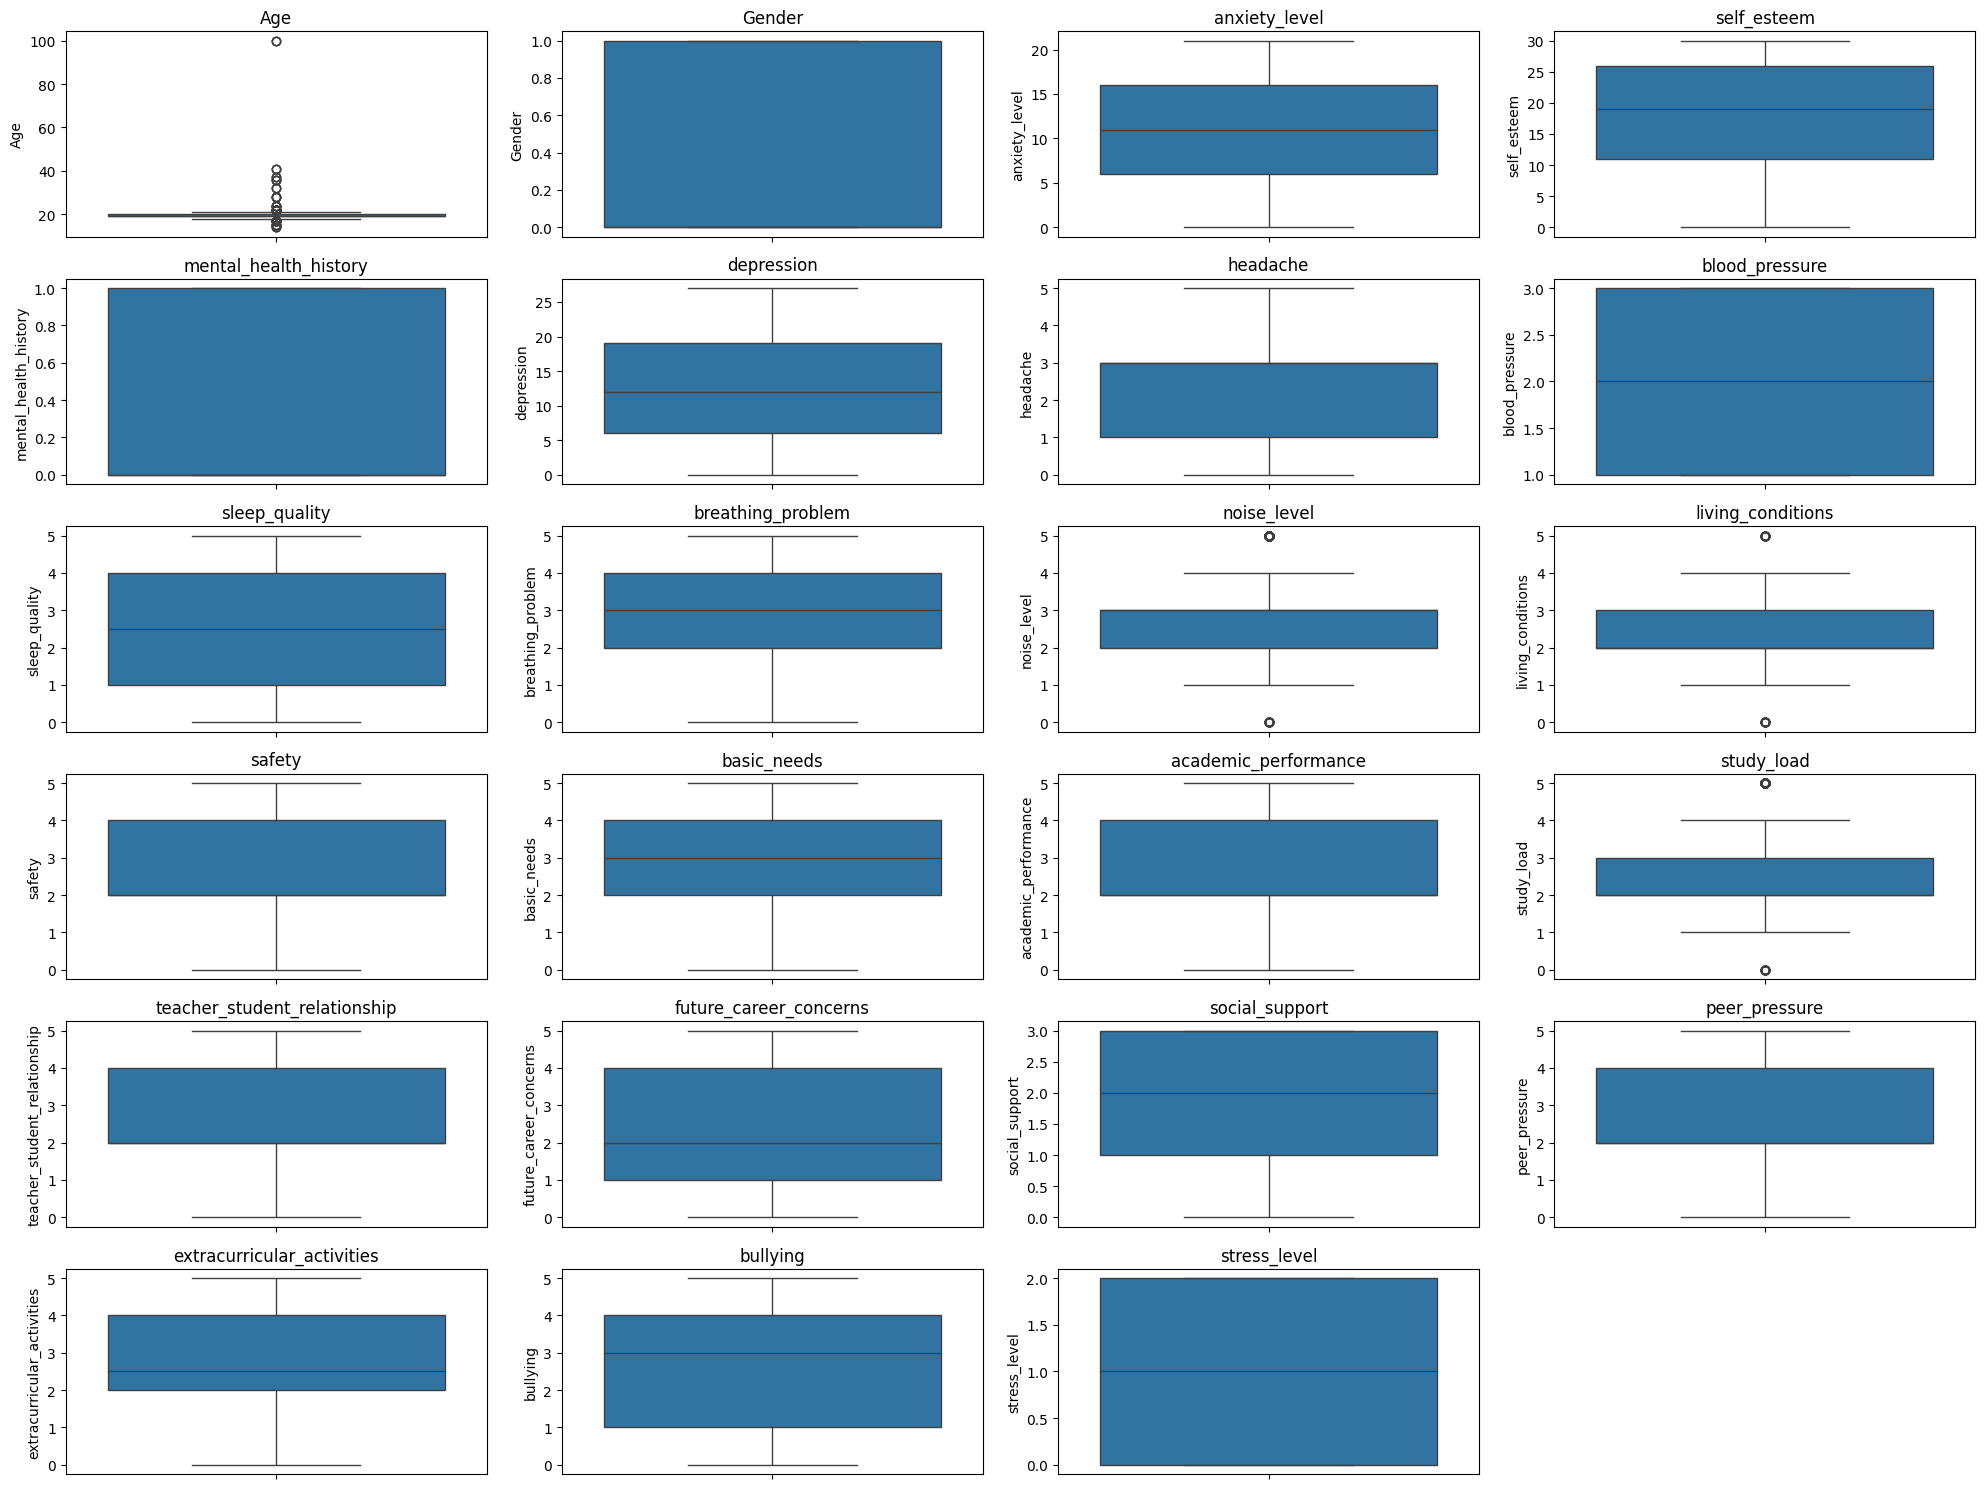

In [14]:
#The box plotting for each feature after removing outliers
plt.figure(figsize=(20,15))
numeric_cols = df_new.select_dtypes(include=np.number).columns
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(6, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## EDA

Target Distribution: Stress Level
stress_level
0    40.353090
1    39.974779
2    19.672131
Name: proportion, dtype: float64


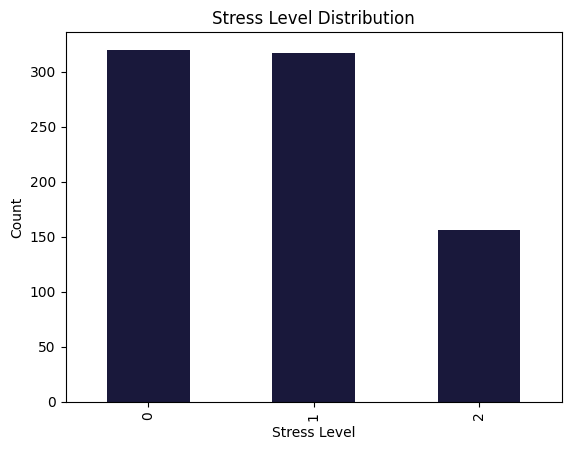

In [15]:
if "stress_level" in df_new.columns:
    print("Target Distribution: Stress Level")
    print(df_new["stress_level"].value_counts(normalize=True)*100)
    df_new["stress_level"].value_counts().plot(kind="bar", color="#19183B")
    plt.title("Stress Level Distribution")
    plt.xlabel("Stress Level")
    plt.ylabel("Count")

    plt.show()
    #That means that no one is maximum stressed

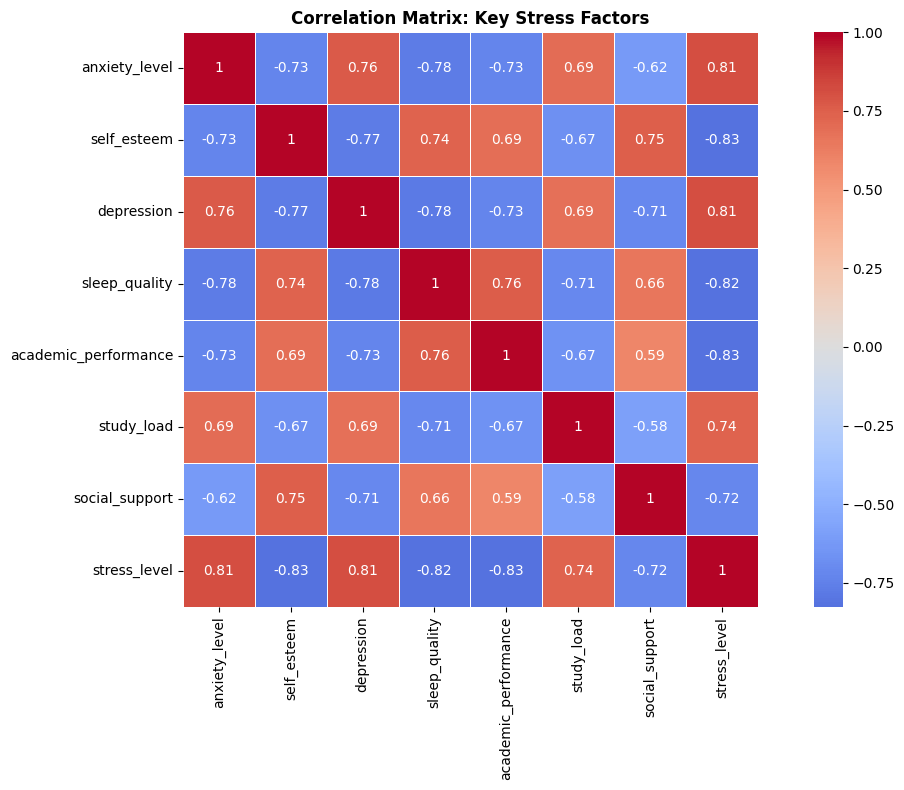

In [16]:
plt.figure(figsize=(12, 8))
key_factors = ['anxiety_level', 'self_esteem', 'depression', 'sleep_quality',
               'academic_performance', 'study_load', 'social_support', 'stress_level']
correlation_matrix = df_new[key_factors].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix: Key Stress Factors', fontweight='bold')
plt.tight_layout()
plt.show()

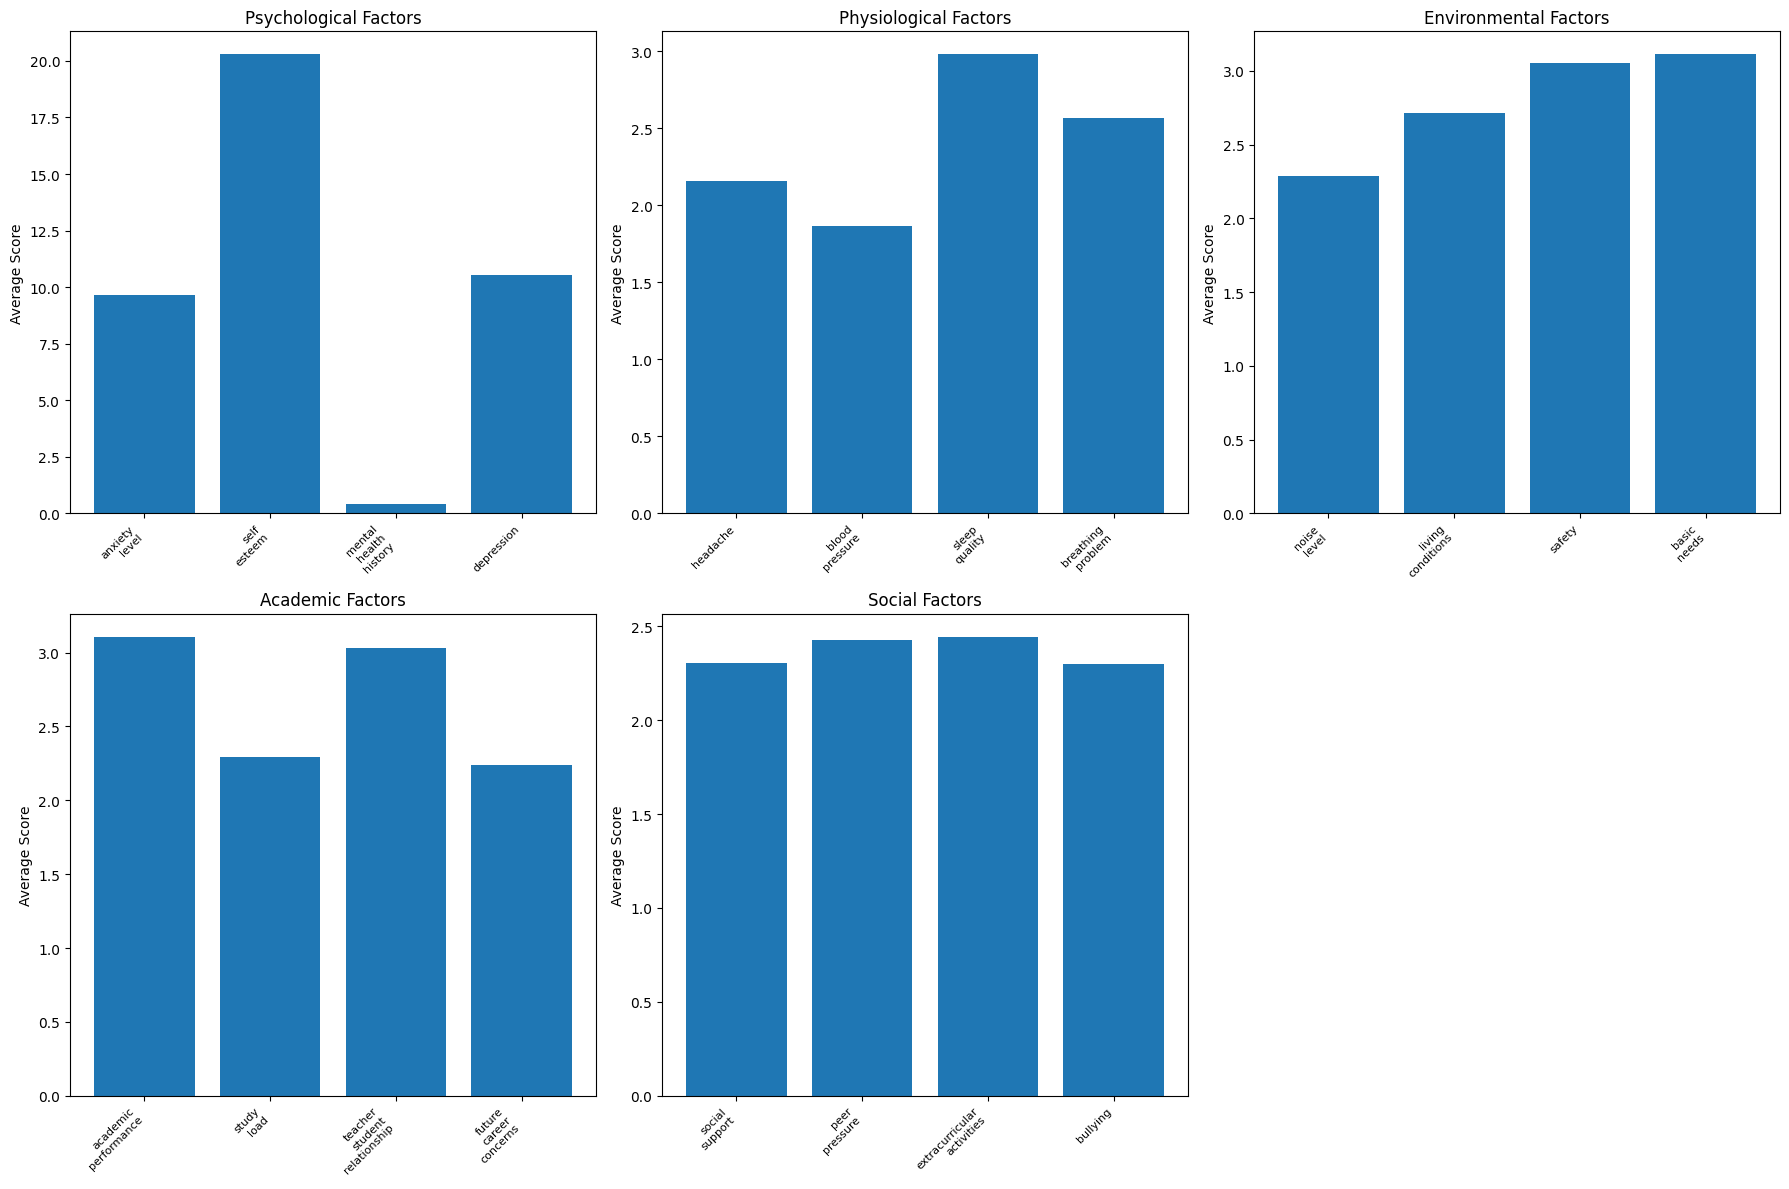

In [17]:
categories = {
    'Psychological': ['anxiety_level', 'self_esteem', 'mental_health_history', 'depression'],
    'Physiological': ['headache', 'blood_pressure', 'sleep_quality', 'breathing_problem'],
    'Environmental': ['noise_level', 'living_conditions', 'safety', 'basic_needs'],
    'Academic': ['academic_performance', 'study_load', 'teacher_student_relationship', 'future_career_concerns'],
    'Social': ['social_support', 'peer_pressure', 'extracurricular_activities', 'bullying']
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, (category, factors) in enumerate(categories.items()):
    if i < 5:
        category_mean = df_new[factors].mean()
        axes[i].bar(range(len(category_mean)), category_mean.values)
        axes[i].set_title(f'{category} Factors')
        axes[i].set_xticks(range(len(category_mean)))
        axes[i].set_xticklabels([f.replace('_', '\n') for f in category_mean.index],
                               rotation=45, ha='right', fontsize=8)
        axes[i].set_ylabel('Average Score')

# Remove the last empty subplot #
axes[5].remove()
plt.tight_layout()
plt.show()

Demographics: Age
Age
19.0     204
20.0     173
18.0      87
21.0      87
22.0      19
17.0      18
28.0       5
24.0       4
15.0       4
14.0       3
32.0       3
100.0      3
36.0       3
37.0       2
41.0       2
Name: count, dtype: int64


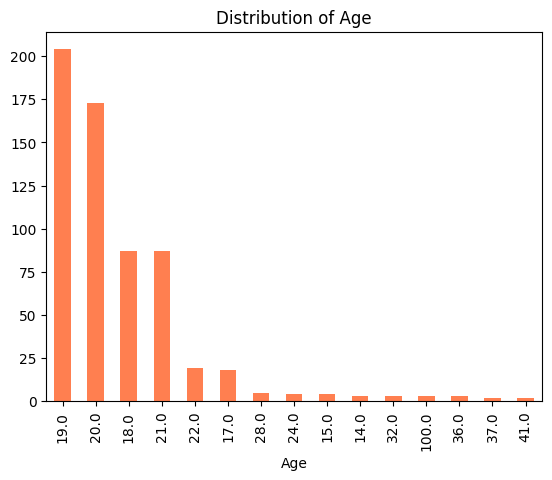

Demographics: Gender
Gender
0.0    411
1.0    206
Name: count, dtype: int64


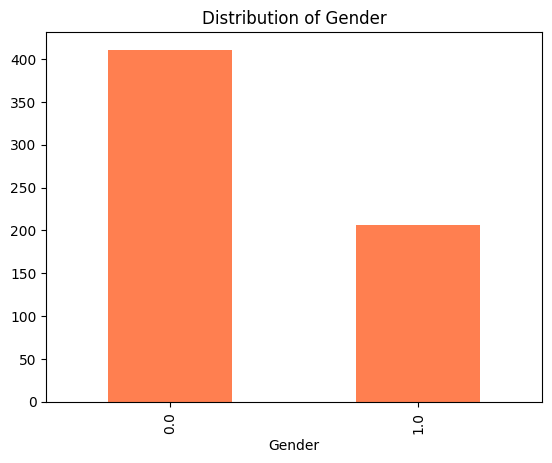

In [18]:
demo_cols = [c for c in df if "Age" in c or "Gender" in c]
for c in demo_cols:
    print(f"Demographics: {c}")
    print(df_new[c].value_counts())
    df_new[c].value_counts().plot(kind="bar", color="coral")
    plt.title(f"Distribution of {c}")
    plt.show()

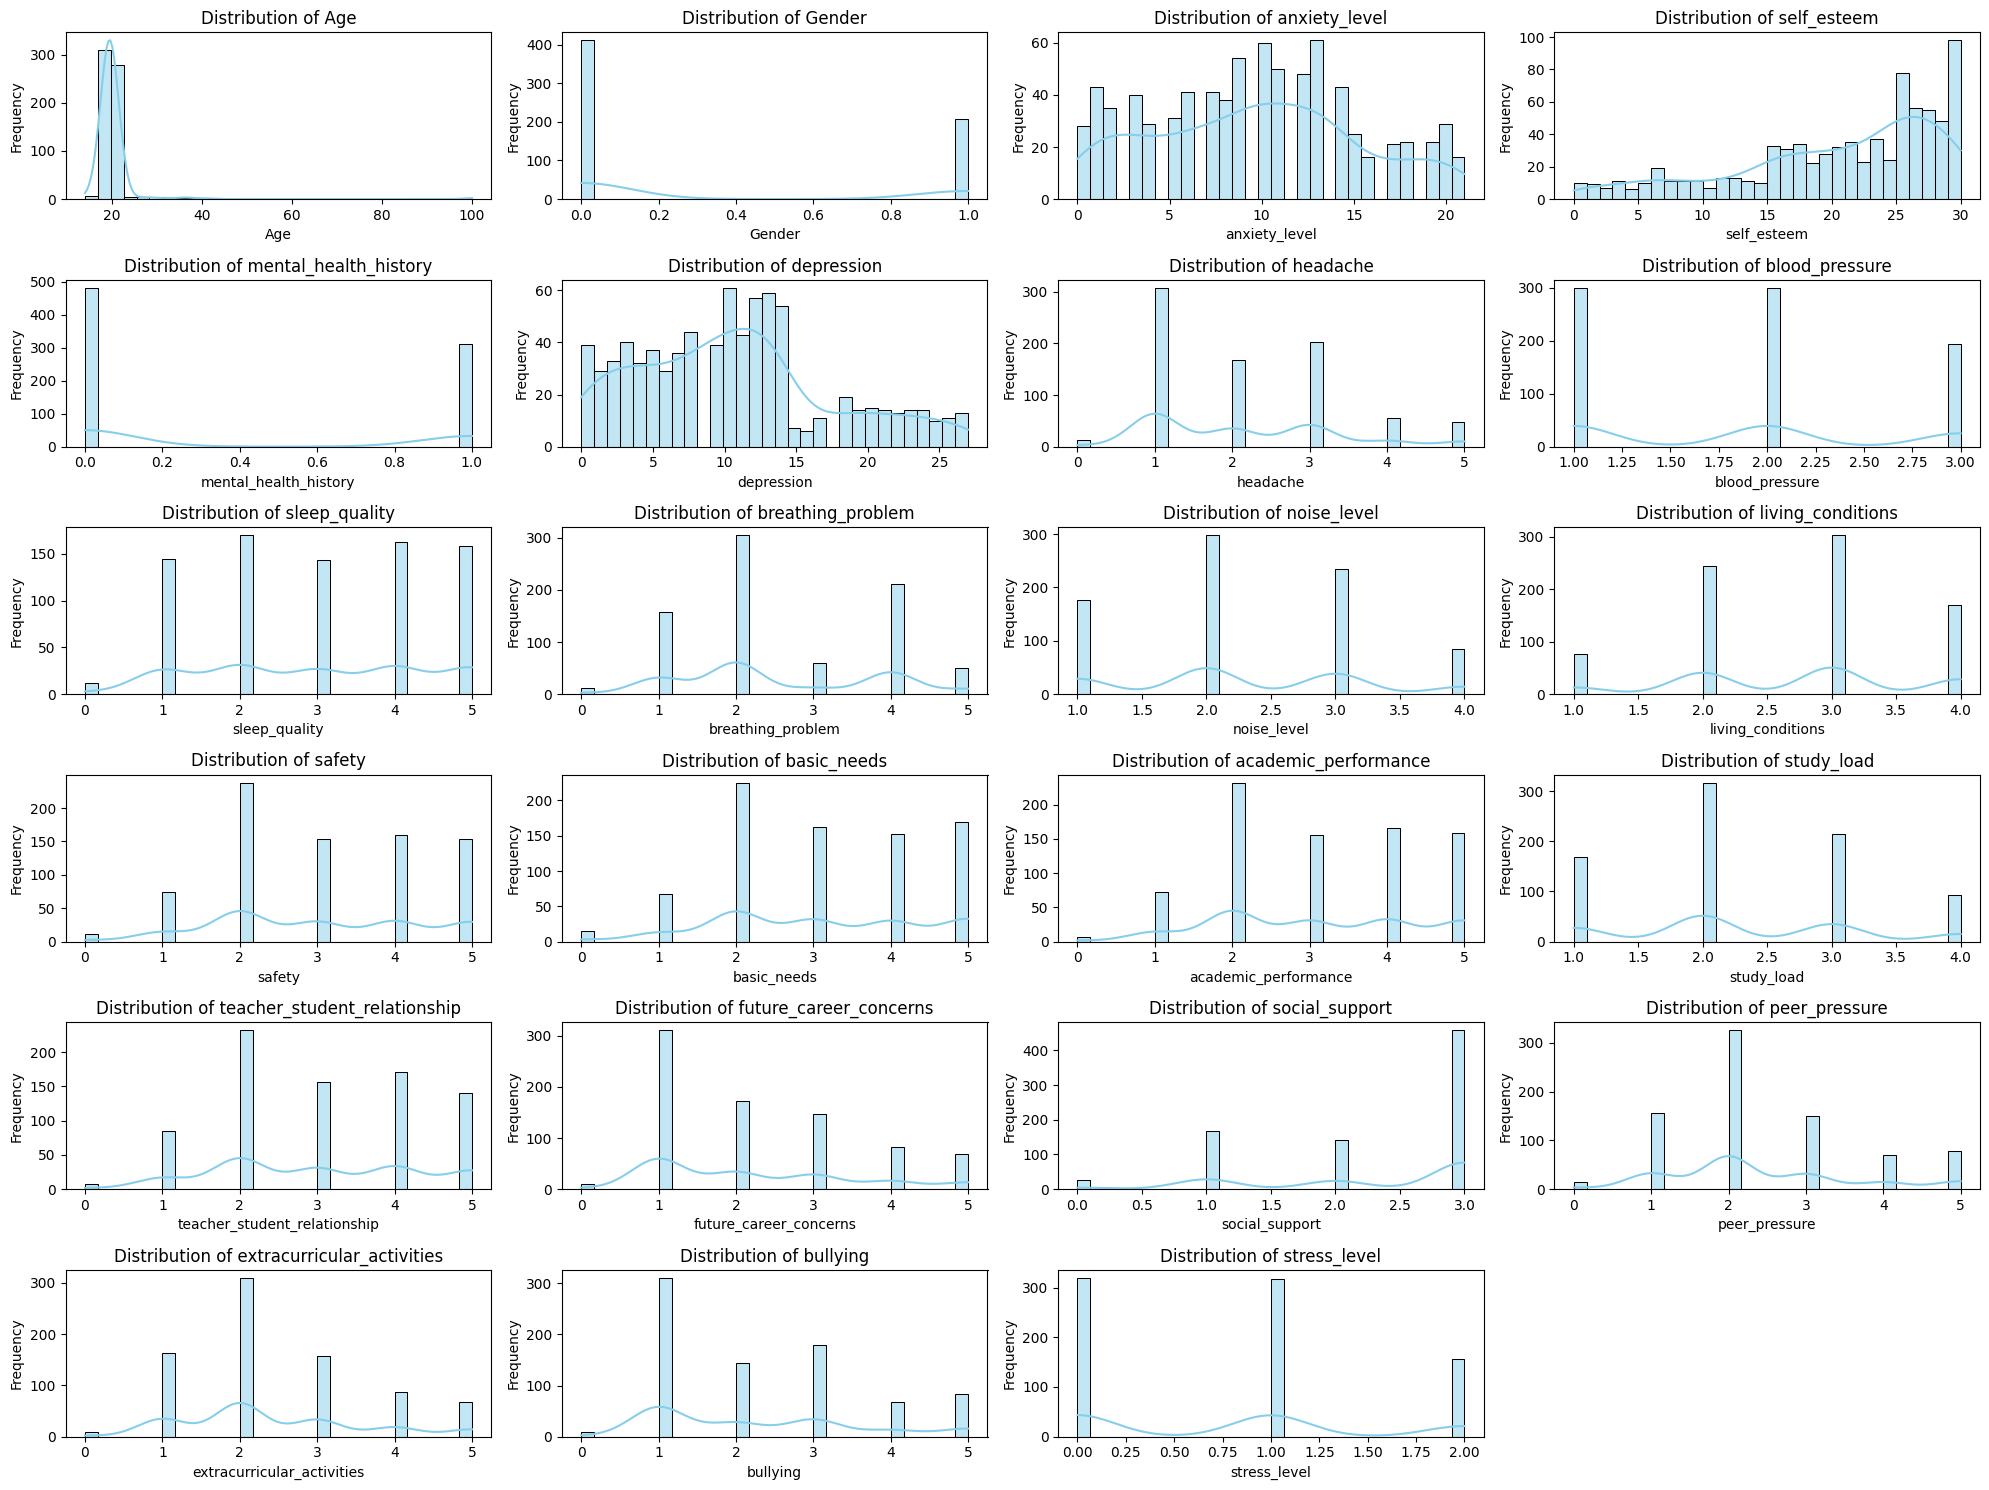

In [19]:
plt.figure(figsize=(20,15))
numeric_cols = df_new.select_dtypes(include=np.number).columns
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(6, 4, i)
    sns.histplot(df_new[col].dropna(), kde=True, bins=30, color="skyblue")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Modeling

In [20]:
numeric_cols=numeric_cols.drop('stress_level')

In [21]:
# Encoding categorical variables
for col in df_new.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df_new[col] = le.fit_transform(df_new[col])

In [22]:
# Scaling numerical variables
scaler = StandardScaler()
df_new[numeric_cols] = scaler.fit_transform(df_new[numeric_cols])

In [23]:
print("Encoding and Scaling completed. Data ready for ML models.")
print("Final dataset shape:", df_new.shape)

Encoding and Scaling completed. Data ready for ML models.
Final dataset shape: (793, 23)


In [24]:
models=list()
models.append(('SVC',SVC()))
models.append(('DT',DecisionTreeClassifier()))
models.append((('KNN'),KNeighborsClassifier()))

In [25]:
imputer2=SimpleImputer(strategy='most_frequent')
df_new['Gender']=imputer2.fit_transform(df_new[['Gender']])[:,0]

In [26]:
df_new['Gender'].isnull().sum()

np.int64(0)

In [27]:
cols_to_impute = ["Age"]
imputer = KNNImputer(n_neighbors=3)
df_new[cols_to_impute] = imputer.fit_transform(df_new[cols_to_impute])

In [28]:
df_new['Age'].isnull().sum()

np.int64(0)

In [29]:
x=df_new.drop('stress_level',axis=1)
y=df_new['stress_level']
x_train, x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [30]:
df_new['stress_level'].unique()

array([1, 2, 0])

In [31]:
# Defining the parameter grid for each model
param_grid= {
        "SVC": {
     "SVC__C":[0.1,1,3,5,9],
     "SVC__kernel":['poly','rbf','linear'],
     "SVC__gamma":[0.4,0.5,0.7,0.8],
     "SVC__degree":[2,3,4], 
     "SVC__probability": [True]
      },
   "DT":{
        "DT__criterion": ["gini", "entropy", "log_loss"],   
        "DT__max_depth": [3, 5, 7, None],
        "DT__min_samples_split": [2, 5, 10],
        "DT__min_samples_leaf": [1, 2, 4]
    },
        "KNN":{
        "KNN__n_neighbors":[1,2,3,5,7,6,8,10],
        "KNN__weights":["distance","uniform"],
        "KNN__metric":['euclidean', 'manhattan', 'minkowski']
        } 

}

In [32]:
from sklearn.preprocessing import label_binarize

### Evaluation

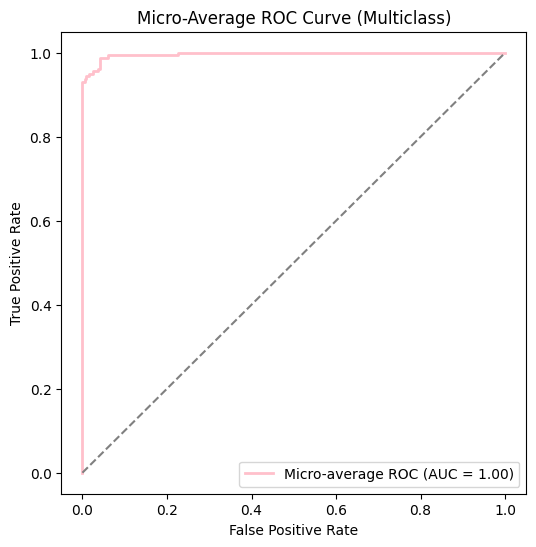

best parameters for SVC are:
 {'SVC__C': 0.1, 'SVC__degree': 2, 'SVC__gamma': 0.4, 'SVC__kernel': 'poly', 'SVC__probability': True}
classification report               precision    recall  f1-score   support

           0       0.95      0.98      0.97        64
           1       0.95      0.94      0.94        63
           2       0.90      0.88      0.89        32

    accuracy                           0.94       159
   macro avg       0.94      0.93      0.93       159
weighted avg       0.94      0.94      0.94       159

train accuracy: 1.0
test accuracy: 0.9511186101737282
F1score:0.9430642369510294
confussion matrix:[[63  0  1]
 [ 2 59  2]
 [ 1  3 28]]



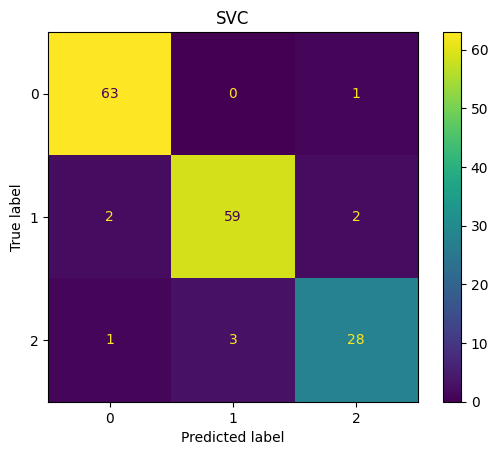

----------------------------------------------------------------------------------------------------


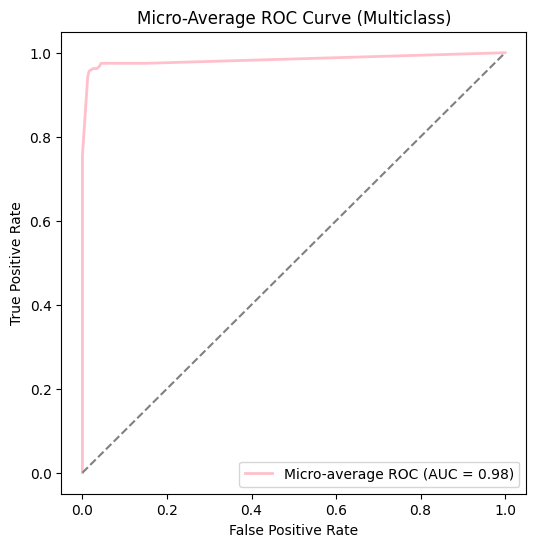

best parameters for DT are:
 {'DT__criterion': 'gini', 'DT__max_depth': 3, 'DT__min_samples_leaf': 1, 'DT__min_samples_split': 5}
classification report               precision    recall  f1-score   support

           0       0.96      1.00      0.98        64
           1       1.00      0.92      0.96        63
           2       0.88      0.94      0.91        32

    accuracy                           0.96       159
   macro avg       0.95      0.95      0.95       159
weighted avg       0.96      0.96      0.96       159

train accuracy: 0.966879435928497
test accuracy: 0.9574178227721536
F1score:0.9561129210743604
confussion matrix:[[64  0  0]
 [ 1 58  4]
 [ 2  0 30]]



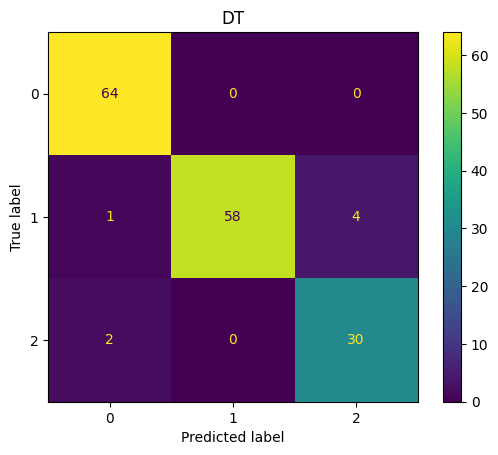

----------------------------------------------------------------------------------------------------


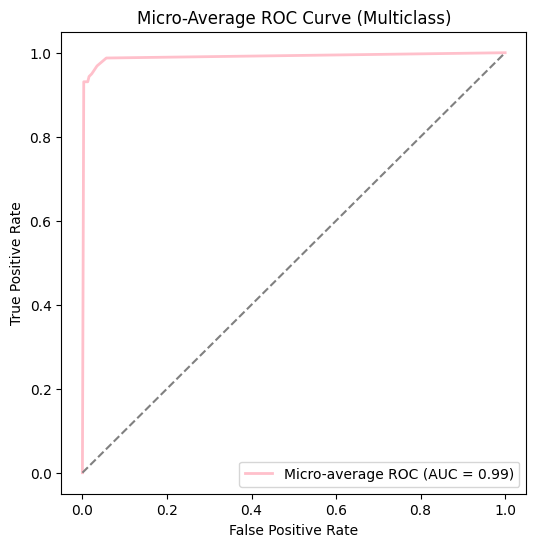

best parameters for KNN are:
 {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 6, 'KNN__weights': 'uniform'}
classification report               precision    recall  f1-score   support

           0       0.98      0.97      0.98        64
           1       0.94      0.97      0.95        63
           2       0.90      0.88      0.89        32

    accuracy                           0.95       159
   macro avg       0.94      0.94      0.94       159
weighted avg       0.95      0.95      0.95       159

train accuracy: 0.9613552004224324
test accuracy: 0.9527059117610298
F1score:0.9495566567347321
confussion matrix:[[62  1  1]
 [ 0 61  2]
 [ 1  3 28]]



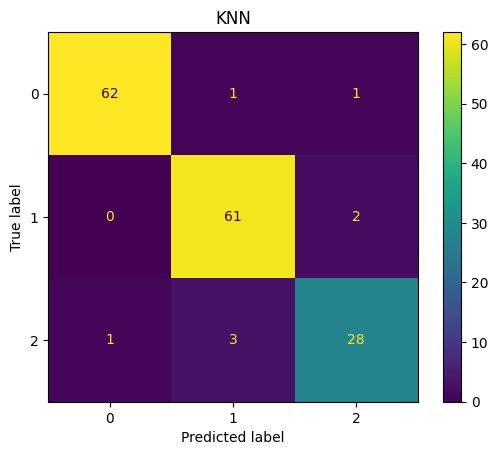

----------------------------------------------------------------------------------------------------


In [33]:
results = []
# Looping through each model, performing GridSearchCV, evaluating, and storing results
for model_name,model in models:
    steps=list()
    steps.append((model_name,model))
    pipeline=Pipeline(steps=steps)
    grid_search=GridSearchCV(estimator=pipeline,cv=5,param_grid=param_grid[model_name],scoring='accuracy',return_train_score=True,n_jobs=-1)
    grid_search.fit(x_train,y_train)


    best_model=grid_search.best_estimator_
    y_predict=best_model.predict(x_test)
    y_proba = best_model.predict_proba(x_test)
  
    


    conf_matrix=confusion_matrix(y_test,y_predict)
    f1_sc = f1_score(y_test, y_predict, average="weighted")
    
    
   
    classes = np.unique(y_test)
    y_test_bin = label_binarize(y_test, classes=classes)
   # micro-average ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, color='pink', lw=2, label=f'Micro-average ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # diagonal
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Micro-Average ROC Curve (Multiclass)')
    plt.legend(loc="lower right")
    plt.savefig(f"results/roc_curve_{model_name}.png")
    plt.show()
    


    # Saving the best model
    with open(f"models/{model_name}_best.pkl", "wb") as f:
     pickle.dump(best_model, f)

    print(f"best parameters for {model_name} are:\n {grid_search.best_params_}") 
    print('classification report',classification_report(y_test, y_predict))
    print(f"train accuracy: {grid_search.cv_results_['mean_train_score'][grid_search.best_index_]}")
    print(f"test accuracy: {grid_search.cv_results_['mean_test_score'][grid_search.best_index_]}")
    print(f'F1score:{f1_sc}')
    print(f"confussion matrix:{conf_matrix}\n")
    vis_cm= ConfusionMatrixDisplay(conf_matrix)
    vis_cm.plot()
    plt.title(model_name) 
    plt.savefig(f"results/confusion_matrix_{model_name}.png")
    plt.show()
    print("-"*100)
   
    # Storing results for summary
    results.append({
        "Model": model_name,
        "Best Params": grid_search.best_params_,
        "Train Acc": grid_search.cv_results_['mean_train_score'][grid_search.best_index_],
        "Test Acc": grid_search.cv_results_['mean_test_score'][grid_search.best_index_],
        "F1 Score": f1_sc,
        "ROC AUC": roc_auc
    })

In [34]:
pd.set_option('display.max_colwidth', None)
summary_df = pd.DataFrame(results)
display(summary_df)
summary_df.to_csv("results/model_summary.csv", index=False)
summary_df.to_excel("results/model_summary.xlsx", index=False)

,Model,Best Params,Train Acc,Test Acc,F1 Score,ROC AUC
0,SVC,"{'SVC__C': 0.1, 'SVC__degree': 2, 'SVC__gamma': 0.4, 'SVC__kernel': 'poly', 'SVC__probability': True}",1.000000,0.951119,0.943064,0.996578
1,DT,"{'DT__criterion': 'gini', 'DT__max_depth': 3, 'DT__min_samples_leaf': 1, 'DT__min_samples_split': 5}",0.966879,0.957418,0.956113,0.983525
2,KNN,"{'KNN__metric': 'manhattan', 'KNN__n_neighbors': 6, 'KNN__weights': 'uniform'}",0.961355,0.952706,0.949557,0.990200
